In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import yfinance as yf

In [2]:
sectors = {'Chips Production': ['NVDA','AMD','INTC'], 'US Banks': ['JPM','GS','BAC'], 'EU Auto':['MBG.DE','BMW.DE','STLA']}
comp_list = ['NVDA','AMD','INTC','JPM','GS','BAC','MBG.DE','BMW.DE','STLA']
data = yf.download(comp_list, start='2020-01-01', end='2024-12-31')['Close']
data = data[comp_list]
#last line forces column order to match sector grouping

[*********************100%***********************]  9 of 9 completed


In [3]:
print(data.shape)
#data has 1291 rows (trading days), and 9 columns (9 companies) - looks correct
print(data.head())
#closing prices in head() make sense, Nvidia is pre-split adjusted by yfinance
print(data.isnull().sum())
'''
34 NaNs for US-listed - holidays (for the US market)
16 NaNs for German-listed for the same reason
1-3% of data missing - expected and acceptable 
'''

(1291, 9)
Ticker          NVDA        AMD       INTC         JPM          GS        BAC  \
Date                                                                            
2020-01-02  5.970755  49.099998  53.666466  119.036430  202.118896  30.587553   
2020-01-03  5.875186  48.599998  53.013721  117.465584  199.755447  29.952469   
2020-01-06  5.899826  48.389999  52.863773  117.372154  201.799774  29.909554   
2020-01-07  5.971252  48.250000  51.981674  115.376762  203.128159  29.712162   
2020-01-08  5.982451  47.830002  52.016956  116.276802  205.086166  30.012539   

Ticker         MBG.DE     BMW.DE      STLA  
Date                                        
2020-01-02  28.898634  52.578617  9.363969  
2020-01-03  28.375309  51.941048  8.997605  
2020-01-06  28.222067  51.749783  8.972768  
2020-01-07  28.447594  52.578617  8.811319  
2020-01-08  28.606611  52.713219  8.848577  
Ticker
NVDA      34
AMD       34
INTC      34
JPM       34
GS        34
BAC       34
MBG.DE    16
BMW.DE   

'\n34 NaNs for US-listed - holidays (for the US market)\n16 NaNs for German-listed for the same reason\n1-3% of data missing - expected and acceptable \n'

In [4]:
data = data.ffill()
#filling missing values with previous day's price
print(data.isnull().sum())
#double check, should've get 0 for all

Ticker
NVDA      0
AMD       0
INTC      0
JPM       0
GS        0
BAC       0
MBG.DE    0
BMW.DE    0
STLA      0
dtype: int64


In [5]:
returns = data.pct_change()
returns = returns.dropna()
#delated 1st row with NaNs, because it's not possible to calculate pct_change for the 1st day

print(returns.describe())
#NVDIA and AMD are the most volatile
#NVIDIA has the highest average daily return - almost 0.3%

Ticker         NVDA          AMD         INTC          JPM           GS  \
count   1290.000000  1290.000000  1290.000000  1290.000000  1290.000000   
mean       0.002990     0.001239    -0.000399     0.000725     0.001000   
std        0.033499     0.032619     0.027020     0.020226     0.020592   
min       -0.184521    -0.146390    -0.260585    -0.149649    -0.127053   
25%       -0.015429    -0.016347    -0.012695    -0.008209    -0.009172   
50%        0.002422     0.000000     0.000000     0.000304     0.000015   
75%        0.021836     0.018982     0.012427     0.009487     0.011069   
max        0.243696     0.165016     0.195213     0.180125     0.175803   

Ticker          BAC       MBG.DE       BMW.DE         STLA  
count   1290.000000  1290.000000  1290.000000  1290.000000  
mean       0.000504     0.000674     0.000466     0.000511  
std        0.022225     0.022728     0.019540     0.025105  
min       -0.153973    -0.188521    -0.129714    -0.216351  
25%       -0.010282

In [6]:
normalized = data / data.iloc[0] * 100
#scaled all companies to start from 100 on a chart

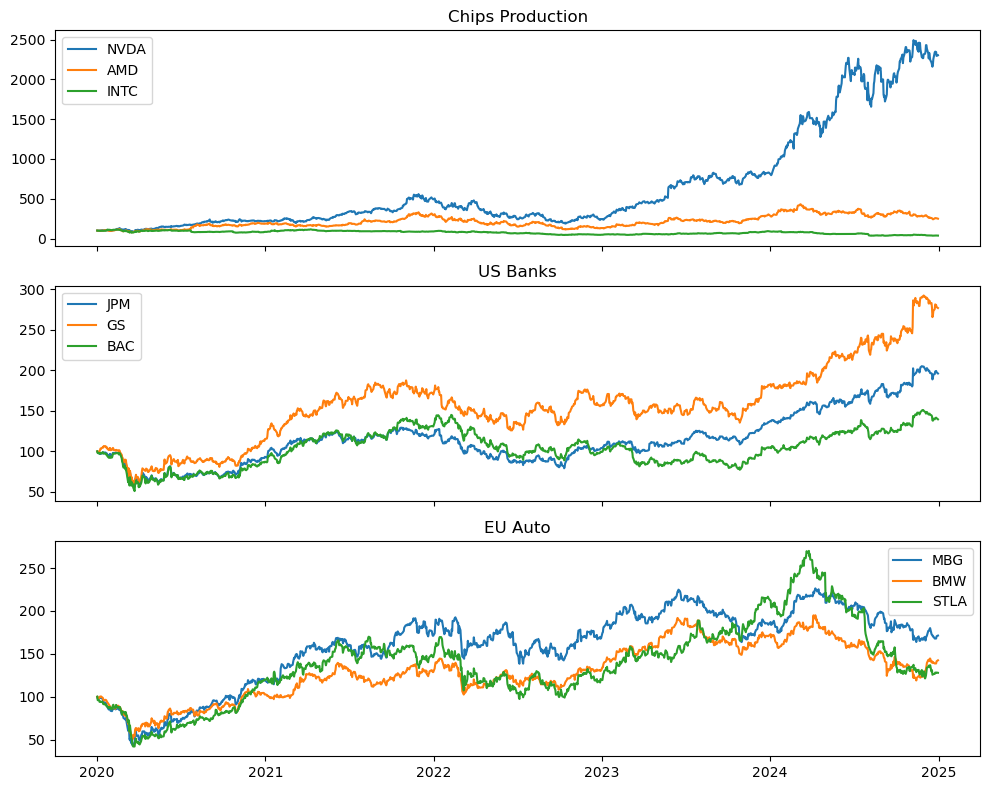

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(normalized.index, normalized['NVDA'], label='NVDA')
axes[0].plot(normalized.index, normalized['AMD'], label='AMD')
axes[0].plot(normalized.index, normalized['INTC'], label='INTC')
axes[0].set_title('Chips Production')
axes[0].legend()
#Chips

axes[1].plot(normalized.index, normalized['JPM'], label='JPM')
axes[1].plot(normalized.index, normalized['GS'], label='GS')
axes[1].plot(normalized.index, normalized['BAC'], label='BAC')
axes[1].set_title('US Banks')
axes[1].legend()
#Banks

axes[2].plot(normalized.index, normalized['MBG.DE'], label='MBG')
axes[2].plot(normalized.index, normalized['BMW.DE'], label='BMW')
axes[2].plot(normalized.index, normalized['STLA'], label='STLA')
axes[2].set_title('EU Auto')
axes[2].legend()
#Auto

plt.tight_layout()
plt.show()

In [8]:
rolling_vol = returns.rolling(window=30).std()
#30-day rolling standard deviation of daily returns
#shows how volatility changed over time, in a less chaotic way

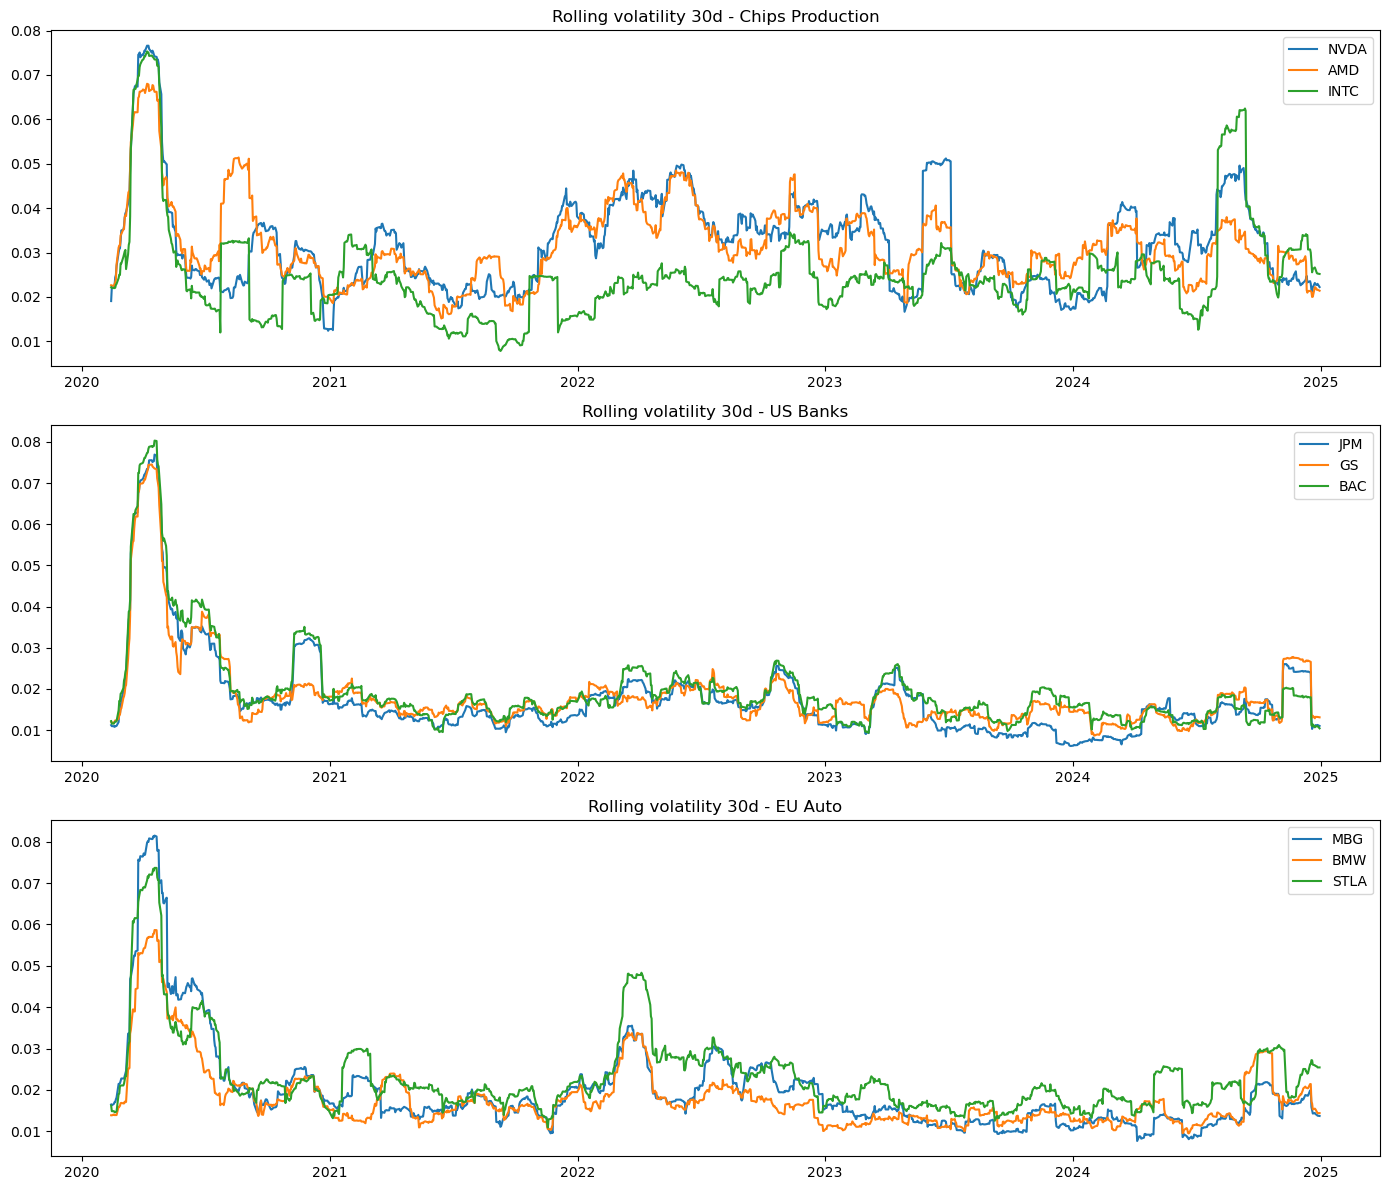

'\nVolatility across all sectors spiked in early 2020 due to COVID\nUS Banks are the most stable overall, returning to low volatility quickly after COVID\nEU Auto shows a second volatility spike in early 2022, likely linked to Ukraine invasion and supply chain disruptions\n'

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# AI and chips
axes[0].plot(rolling_vol.index, rolling_vol['NVDA'], label='NVDA')
axes[0].plot(rolling_vol.index, rolling_vol['AMD'], label='AMD')
axes[0].plot(rolling_vol.index, rolling_vol['INTC'], label='INTC')
axes[0].set_title('Rolling volatility 30d - Chips Production')
axes[0].legend()

# US banks
axes[1].plot(rolling_vol.index, rolling_vol['JPM'], label='JPM')
axes[1].plot(rolling_vol.index, rolling_vol['GS'], label='GS')
axes[1].plot(rolling_vol.index, rolling_vol['BAC'], label='BAC')
axes[1].set_title('Rolling volatility 30d - US Banks')
axes[1].legend()

# EU auto
axes[2].plot(rolling_vol.index, rolling_vol['MBG.DE'], label='MBG')
axes[2].plot(rolling_vol.index, rolling_vol['BMW.DE'], label='BMW')
axes[2].plot(rolling_vol.index, rolling_vol['STLA'], label='STLA')
axes[2].set_title('Rolling volatility 30d - EU Auto')
axes[2].legend()

plt.tight_layout()
plt.show()

Volatility across all sectors spiked in early 2020 due to COVID.
US Banks are the most stable overall, returning to low volatility quickly after COVID.
EU Auto shows a second volatility spike in early 2022, likely linked to Ukraine invasion and supply chain disruptions.

In [10]:
corr_matrix = returns.corr()
print(corr_matrix)

Ticker      NVDA       AMD      INTC       JPM        GS       BAC    MBG.DE  \
Ticker                                                                         
NVDA    1.000000  0.746941  0.483359  0.325211  0.394699  0.315099  0.280673   
AMD     0.746941  1.000000  0.486578  0.296393  0.367227  0.311563  0.245863   
INTC    0.483359  0.486578  1.000000  0.416636  0.447581  0.410752  0.269974   
JPM     0.325211  0.296393  0.416636  1.000000  0.828444  0.894937  0.497886   
GS      0.394699  0.367227  0.447581  0.828444  1.000000  0.827891  0.474629   
BAC     0.315099  0.311563  0.410752  0.894937  0.827891  1.000000  0.512040   
MBG.DE  0.280673  0.245863  0.269974  0.497886  0.474629  0.512040  1.000000   
BMW.DE  0.218328  0.199148  0.238044  0.435155  0.410478  0.443943  0.831163   
STLA    0.400340  0.378344  0.404636  0.576600  0.581514  0.583968  0.642315   

Ticker    BMW.DE      STLA  
Ticker                      
NVDA    0.218328  0.400340  
AMD     0.199148  0.378344  
INT

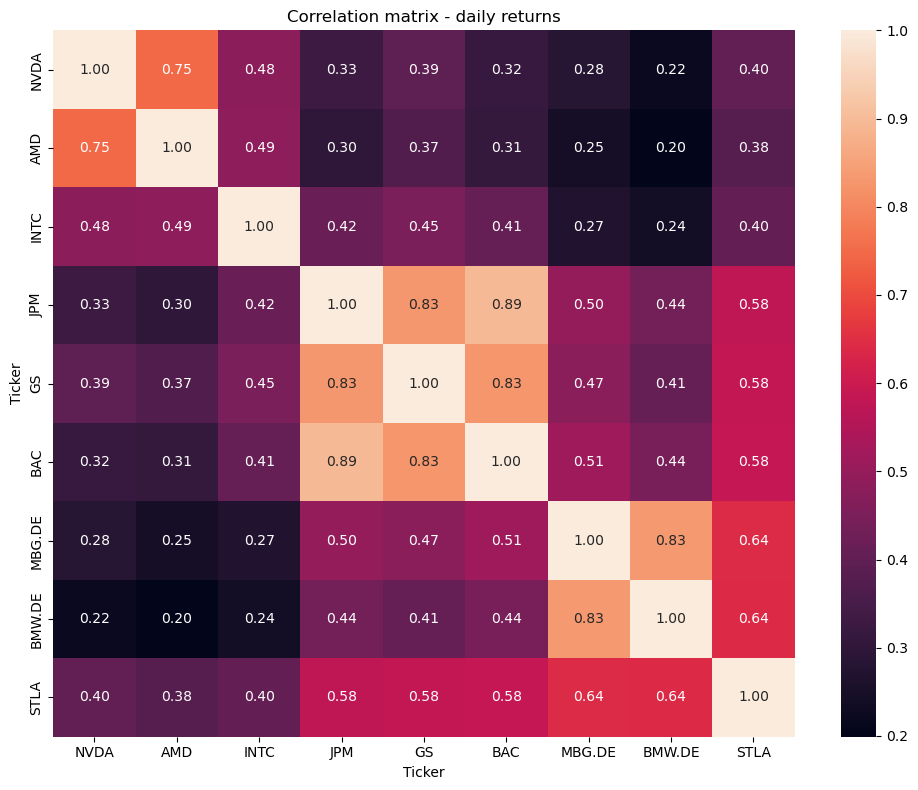

In [11]:
corr_matrix = returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
ax.set_title('Correlation matrix - daily returns')
plt.tight_layout()
plt.show()

Strongest correlation within sectors, 
cross-sector correlation is weak.
Lowest correlation between Chips and EU Auto - these sectors operate 
in very different market environments.
Banks and Chips show slightly higher cross-sector correlation.
Banks and EU Auto correlation is higher, both are more tied to macroeconomic cycles.


Stellantis shows an unusually high correlation with banks - possibly because 
it sells lower-segment cars (Fiat, Opel) more dependent on consumer credit, 
unlike BMW and Mercedes which target wealthier buyers. Its customers may be 
more sensitive to the same macroeconomic factors that drive bank stocks.